# 04 — Learning the Butcher Tableau: the Runge–Kutta Neural Network

**Learned Iterative Solvers for AC Power Flow** · Notebook 4 of a series

---

Notebook 02 hit a wall. We froze a linear combination over a subspace generated by raw
powers $\mathbf{A}^j\mathbf{b}$, and measured that basis dying past $m\approx5$ —
$\kappa_2(\mathbf{W})>10^{14}$, coefficients meaningless. We worked around it by keeping
$m$ small.

The wall was in the **inner** recurrence, not the outer weights. Powers of $\mathbf{A}$ are
a fixed, and very bad, way to generate a subspace. The fix that [4] and [5] are built
around is to let the inner recurrence carry its *own* learnable coefficients.

This notebook takes the smallest instance of that idea: the Runge–Kutta neural network of
[4], where the learned parameters *are* a Butcher tableau. We work on ODEs rather than
power flow deliberately — the answers are known in closed form, so every claim can be
checked exactly before we trust the machinery on a grid.

The target is [4]'s sharpest result: on a structured family of ODEs, a **two-stage** method
can reach **third** order, which is impossible for general vector fields. And because the
paper derives the exact coefficients analytically, we can ask the hard question — not
"does training help?" but **"does training find the provably correct answer?"**

### References

| | |
|---|---|
| **[1]** | Monga, Li & Eldar, *Algorithm Unrolling*, IEEE SPM 38(2), 2021 |
| **[2]** | Gregor & LeCun, *Learning Fast Approximations of Sparse Coding*, ICML 2010 |
| **[3]** | Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 |
| **[4]** | Guo, Dietrich, Bertalan, Doncevic, Dahmen, Kevrekidis & Li, *Personalized Algorithm Generation: A Case Study in Learning ODE Integrators*, SIAM J. Sci. Comput. 44(4), A1911–A1933, 2022 |
| **[5]** | Doncevic, Mitsos, Guo, Li, Dietrich, Dahmen & Kevrekidis, *A Recursively Recurrent Neural Network (R2N2) Architecture for Learning Iterative Algorithms*, SIAM J. Sci. Comput. 46(2), 2024 |

In [1]:
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch

from lis.rknn import (RKNN, LINEAR_FAMILY, SQUARE_FAMILY, rk_reference,
                      global_error, taylor_regulariser)
from lis.plotting import use_style, save, stacked, suptitle, PALETTE, plt

use_style()
torch.set_default_dtype(torch.float64)   # errors down to 1e-11; float32 bottoms out at 1e-7
print("torch", torch.__version__, "| default dtype", torch.get_default_dtype())

torch

2.11.0+cu128

| default dtype

torch.float64

---
## 1. Runge–Kutta, with the tableau exposed

An explicit $m$-stage Runge–Kutta step is

$$k_1 = h\,f(y_n),\qquad
  k_i = h\,f\!\Big(y_n + \sum_{j<i}\theta_{i-1,j}k_j\Big),\qquad
  y_{n+1} = y_n + \sum_{i=1}^m \theta_{c_i}k_i$$

This is the *same* generate-then-assemble skeleton we identified inside GMRES in notebook
01 — stages first, weighted sum second. What matters here is that it has **two** sets of
coefficients, and notebook 02 only ever had the second:

| | role | our monomial solver | RK-NN |
|---|---|---|---|
| $\theta_{i,j}$ | **inner** — how each stage is built from the previous ones | fixed: $\mathbf{A}^j\mathbf{b}$ | **learned** |
| $\theta_{c_i}$ | **outer** — how stages combine into the update | learned | learned |

Classically the $\theta$ come from order conditions derived by hand. In [4] they are
trained on a distribution of ODEs.

Two design details worth stating, both from [4] §3.1:

- **Parameter count is $m(m+1)/2$.** For $m=3$ that is six numbers. This "neural network"
  has fewer parameters than a linear regression on six features.
- **Consistency is structural.** The outer weights are a softmax, so $\sum_i\theta_{c_i}=1$
  by construction. [4]'s Proposition 3.1 then gives $\hat y_{n+1}=y_n+hf(y_n)+o(h)$ for
  *any* parameter values — no amount of bad training can produce something that fails to
  converge as $h\to0$. Only the *order* is at stake, never consistency.

That last point is the same safeguarding instinct as notebook 02's fallback-to-Newton:
put the guarantee in the architecture, not in the training.

In [2]:
net = RKNN(m=3, seed=0)
print(f"m=3 RK-NN: {sum(p.numel() for p in net.parameters())} trainable parameters "
      f"= m(m+1)/2 = {3*4//2}")
print("\ninner coefficients (strictly lower triangular):\n", net.inner_matrix().detach().numpy())
print("outer weights (softmax, sums to 1):", net.weights.detach().numpy(),
      " sum =", float(net.weights.sum()))

print("\nClassical methods encoded in the same parametrization, so comparisons differ")
print("only in the coefficients and never in the code path:")
for order in [2, 3, 4]:
    t = rk_reference(order).tableau()
    print(f"  RK{order}: weights = {np.round(t['weights'], 4)}")

m=3 RK-NN: 6 trainable parameters = m(m+1)/2 = 6


inner coefficients (strictly lower triangular):


[[ 0.          0.          0.        ]
 [ 0.77049805  0.          0.        ]
 [-0.14671445 -1.08939469  0.        ]]

outer weights (softmax, sums to 1):

[0.33333333 0.33333333 0.33333333]

...


Classical methods encoded in the same parametrization, so comparisons differ

only in the coefficients and never in the code path:

  RK2: weights = [0.5 0.5]

  RK3: weights = [0.1667 0.6667 0.1667]

  RK4: weights = [0.1667 0.3333 0.3333 0.1667]

In [3]:
# Do the classical references reproduce their textbook orders in our implementation?
rows = []
for fam in [LINEAR_FAMILY, SQUARE_FAMILY]:
    a, y0 = fam.sample(32, torch.Generator().manual_seed(0))
    hs = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])
    for order in [2, 3, 4]:
        net = rk_reference(order)
        es = np.array([float(global_error(net, fam, y0, a, h, 1.0).mean()) for h in hs])
        rows.append({"family": fam.name, "method": f"RK{order}", "expected order": order,
                     "measured slope": np.polyfit(np.log(hs), np.log(es), 1)[0]})
ref_df = pd.DataFrame(rows)
display(ref_df.style.format({"measured slope": "{:.2f}"}).hide(axis="index"))
print("Slopes sit slightly above the nominal order because the fit includes finite h;")
print("the ordering and separation are unambiguous, so the machinery is sound.")

family,method,expected order,measured slope
linear,RK2,2,2.09
linear,RK3,3,3.09
linear,RK4,4,4.10
square,RK2,2,2.02
square,RK3,3,3.06
square,RK4,4,3.99


Slopes sit slightly above the nominal order because the fit includes finite h;

the ordering and separation are unambiguous, so the machinery is sound.

---
## 2. The order barrier, and how a structured family breaks it

For a *general* vector field, an explicit $m$-stage RK method has order $p \le m$ (and for
$p\ge5$, strictly $m\ge p+1$). A two-stage method cannot be third order. That is a theorem.

But it is a theorem about **all** Lipschitz $f$. Restrict to a structured family and the
order conditions become fewer, because fewer distinct elementary differentials appear.
[4] §4.3 works this out for the square family $\dot y = -ay^2$. Substituting the two-stage
scheme:

$$k_1 = -a y_n^2 h,\qquad k_2 = -ay_n^2h + 2\theta_1a^2y_n^3h^2 - \theta_1^2a^3y_n^4h^3$$

$$\hat y_{n+1} = y_n - (\theta_{c1}{+}\theta_{c2})\,ay_n^2h + 2\theta_1\theta_{c2}\,a^2y_n^3h^2 - \theta_1^2\theta_{c2}\,a^3y_n^4h^3$$

while the true solution $y(t) = (at+1/y_0)^{-1}$ expands as

$$y(t_{n+1}) = y_n - ay_n^2h + a^2y_n^3h^2 - a^3y_n^4h^3 + O(h^4)$$

Matching coefficients gives **three** conditions ([4] eq. 23):

$$\theta_{c1}+\theta_{c2}=1,\qquad 2\theta_1\theta_{c2}=1,\qquad \theta_1^2\theta_{c2}=1$$

which have a **unique** solution: dividing the third by the second gives $\theta_1/2=1$, so

$$\boxed{\;\theta_1 = 2,\qquad \theta_{c1}=0.75,\qquad \theta_{c2}=0.25\;}$$

Classical RK2 (Heun) has $\theta_1=1,\ \theta_c=(0.5,0.5)$, which satisfies the first two
conditions but not the third — hence order 2. Let us confirm all of this numerically
before asking anything of a learning algorithm.

In [4]:
def two_stage(theta1, theta_c2):
    "A two-stage RK-NN with the given coefficients, bypassing training."
    net = RKNN(2)
    with torch.no_grad():
        net.inner.copy_(torch.tensor([float(theta1)]))
        net.logits.copy_(torch.log(torch.tensor([1.0 - theta_c2, theta_c2])))
    return net

analytic = two_stage(2.0, 0.25)
a, y0 = SQUARE_FAMILY.sample(32, torch.Generator().manual_seed(0))
hs = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625, 0.003125, 0.0015625])

curves = {}
for label, net in [("analytic 2-stage (2, 0.75, 0.25)", analytic),
                   ("classical RK2 (Heun)", rk_reference(2)),
                   ("classical RK3", rk_reference(3))]:
    curves[label] = np.array([float(global_error(net, SQUARE_FAMILY, y0, a, h, 1.0).mean())
                              for h in hs])

print(f"{'method':<34}{'slope':>8}{'stages':>9}")
for label, es in curves.items():
    stages = 2 if "2-stage" in label or "RK2" in label else 3
    print(f"{label:<34}{np.polyfit(np.log(hs), np.log(es), 1)[0]:>8.2f}{stages:>9}")

print("\nverification of the three order conditions at the analytic point:")
t1, c1, c2 = 2.0, 0.75, 0.25
print(f"  theta_c1 + theta_c2 = {t1*0+c1+c2:.6f}   (target 1)")
print(f"  2*theta_1*theta_c2  = {2*t1*c2:.6f}   (target 1)")
print(f"  theta_1^2*theta_c2  = {t1**2*c2:.6f}   (target 1)")
print(f"\nTaylor regulariser R (alpha=3) at that point: "
      f"{float(taylor_regulariser(analytic, SQUARE_FAMILY, y0, a, 3)):.2e}")
print(f"                              at classical RK2: "
      f"{float(taylor_regulariser(rk_reference(2), SQUARE_FAMILY, y0, a, 3)):.2e}")

method                               slope   stages

analytic 2-stage (2, 0.75, 0.25)      3.04        2

classical RK2 (Heun)                  2.01        2

classical RK3                         3.04        3


verification of the three order conditions at the analytic point:

  theta_c1 + theta_c2 = 1.000000   (target 1)

  2*theta_1*theta_c2  = 1.000000   (target 1)

  theta_1^2*theta_c2  = 1.000000   (target 1)


Taylor regulariser R (alpha=3) at that point: 1.53e-30

                              at classical RK2: 2.51e+01

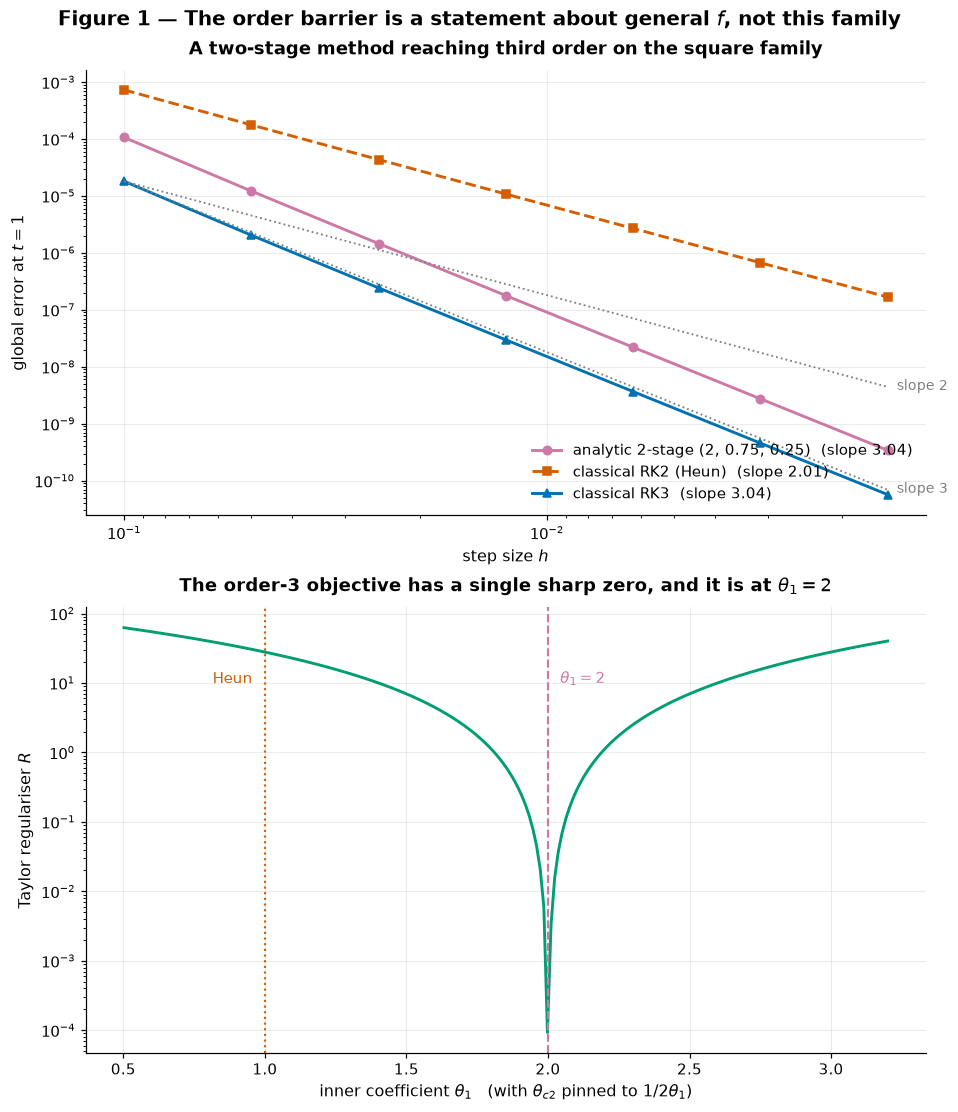

In [5]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)
styles = {"analytic 2-stage (2, 0.75, 0.25)": (PALETTE["learned"], "o-"),
          "classical RK2 (Heun)": (PALETTE["gmres"], "s--"),
          "classical RK3": (PALETTE["newton"], "^-")}
for label, es in curves.items():
    col, st = styles[label]
    ax1.loglog(hs, es, st, color=col, label=f"{label}  (slope {np.polyfit(np.log(hs), np.log(es), 1)[0]:.2f})")
for p, lab in [(2, "slope 2"), (3, "slope 3")]:
    ax1.loglog(hs, curves["classical RK3"][0]*(hs/hs[0])**p, ":", color=PALETTE["ref"], lw=1.2)
    ax1.annotate(lab, (hs[-1], curves["classical RK3"][0]*(hs[-1]/hs[0])**p),
                 fontsize=9, color=PALETTE["ref"], xytext=(6, -2), textcoords="offset points")
ax1.set_xlabel("step size $h$"); ax1.set_ylabel("global error at $t=1$")
ax1.set_title("A two-stage method reaching third order on the square family", pad=10)
ax1.legend(loc="lower right"); ax1.invert_xaxis()

th = np.linspace(0.4, 3.2, 220)
R = [float(taylor_regulariser(two_stage(t, 1/(2*t)), SQUARE_FAMILY, y0[:16], a[:16], 3))
     for t in th]
ax2.semilogy(th, R, color=PALETTE["precond"])
ax2.axvline(2.0, color=PALETTE["learned"], ls="--", lw=1.4)
ax2.annotate(r"$\theta_1 = 2$", xy=(2.0, 1e1), xytext=(8, 0), textcoords="offset points",
             fontsize=10, color=PALETTE["learned"])
ax2.axvline(1.0, color=PALETTE["gmres"], ls=":", lw=1.4)
ax2.annotate("Heun", xy=(1.0, 1e1), xytext=(-8, 0), textcoords="offset points",
             ha="right", fontsize=10, color=PALETTE["gmres"])
ax2.set_xlabel(r"inner coefficient $\theta_1$   (with $\theta_{c2}$ pinned to $1/2\theta_1$)")
ax2.set_ylabel(r"Taylor regulariser $R$")
ax2.set_title(r"The order-3 objective has a single sharp zero, and it is at $\theta_1=2$", pad=10)
suptitle(fig, "Figure 1 — The order barrier is a statement about general $f$, not this family")
save(fig, "04_order_barrier"); plt.show()

**Reading Figure 1.** The top panel confirms the theory: two stages, slope 3. The analytic
tableau beats classical RK2 by an order of magnitude at every $h$ and tracks the *slope* of
RK3 while doing one fewer function evaluation per step.

The bottom panel is the objective a learner would have to minimise, and it is encouraging:
a single sharp zero, exactly at $\theta_1 = 2$, with classical Heun sitting well up the
slope at $\theta_1=1$. No local minima, no flat valley. If learning cannot find this, the
problem is the optimiser, not the landscape.

---
## 3. The training objective

[4] combines two terms.

**Scaled squared loss** (eq. 14), a one-step prediction error normalised by the reference
method's error so it does not vanish as $h\to0$:

$$L = \frac{\lVert y_1 - \hat y_1\rVert^2}{\lVert y_1 - \hat y_1^{(RK)}\rVert^2}$$

**Taylor regulariser** (eq. 16), which promotes order $\alpha$ directly. Global order
$\alpha$ requires local truncation error $O(h^{\alpha+1})$, i.e. the first $\alpha$
$h$-derivatives of the one-step error must vanish at $h=0$:

$$R = \sum_{i=1}^{\alpha}\left\lVert \frac{d^i}{dh^i}\Big|_{h=0}\big(y_1-\hat y_1\big)\right\rVert_2^2$$

These derivatives are taken **at exactly $h=0$** by repeated automatic differentiation.
That is what makes $R$ a statement about *order* rather than about accuracy at whichever
step sizes happened to be sampled.

> **An implementation trap worth recording.** $h$ must be a **vector**, one entry per batch
> element. Differentiating with respect to a single shared scalar returns the derivative of
> the *sum*; re-broadcasting that back over the batch multiplies the penalty by the batch
> size at every derivative order, so $R$ grows like $n^\alpha$. Measured on classical RK2:
> the scalar-$h$ version gave $R = 141,\ 4.1\times10^5,\ 1.5\times10^9$ for batches of
> 1, 4, 16 — while the correct per-element version gives $141,\ 155,\ 266$, growing linearly
> as a sum should. The wrong version trains to something, which is what makes it dangerous.

---
## 4. Can training find the provably correct tableau?

This is the question the analytic solution lets us ask properly. We know the answer is
$(2,\,0.75,\,0.25)$. Does gradient descent on [4]'s objective get there?

In [6]:
def train(net, family, alpha, epochs=4000, batch=128, lr=1e-2, seed=0,
          w_mse=1.0, w_reg=1.0, ref_order=None, h_range=(0.01, 0.10), track_every=0):
    "Train an RK-NN. Returns (net, history) where history logs the coefficient path."
    g = torch.Generator().manual_seed(seed)
    ref = rk_reference(ref_order or alpha)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    hist = []
    for ep in range(epochs):
        a_, y_ = family.sample(batch, g)
        h = h_range[0] + (h_range[1]-h_range[0])*torch.rand(batch, generator=g)
        loss = torch.zeros(())
        mse = torch.zeros(())
        if w_mse:
            y1 = family.exact(y_, a_, h)
            yhat = net.step(family, y_, a_, h)
            with torch.no_grad():
                yref = ref.step(family, y_, a_, h)
            mse = ((y1 - yhat)**2 / ((y1 - yref)**2 + 1e-30)).mean()
            loss = loss + w_mse*mse
        reg = taylor_regulariser(net, family, y_, a_, alpha)
        if w_reg:
            loss = loss + w_reg*reg
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if track_every and ep % track_every == 0:
            t = net.tableau()
            hist.append((ep, float(mse), float(reg),
                         t["inner"][1, 0] if net.m > 1 else 0.0, t["weights"][-1]))
    return net, hist

configs = [("scaled MSE + regulariser", dict(w_mse=1.0, w_reg=1.0)),
           ("scaled MSE only",          dict(w_mse=1.0, w_reg=0.0)),
           ("regulariser only",         dict(w_mse=0.0, w_reg=1.0))]

t0 = time.time()
results, tracks = [], {}
for label, kw in configs:
    for seed in [0, 1, 2]:
        net, hist = train(RKNN(2, seed=seed), SQUARE_FAMILY, alpha=3, epochs=4000,
                          seed=seed, ref_order=3, track_every=100, **kw)
        t = net.tableau()
        th1, thc2 = t["inner"][1, 0], t["weights"][1]
        es = np.array([float(global_error(net, SQUARE_FAMILY, y0, a, h, 1.0).mean()) for h in hs])
        results.append({"objective": label, "seed": seed, "theta_1": th1, "theta_c2": thc2,
                        "|theta_1 - 2|": abs(th1 - 2.0),
                        "slope": np.polyfit(np.log(hs), np.log(es), 1)[0],
                        "R": float(taylor_regulariser(net, SQUARE_FAMILY, y0, a, 3))})
        if seed == 0:
            tracks[label] = hist
train_df = pd.DataFrame(results)
print(f"({time.time()-t0:.0f} s)")
display(train_df.style.format({"theta_1": "{:.4f}", "theta_c2": "{:.4f}",
                               "|theta_1 - 2|": "{:.1e}", "slope": "{:.2f}",
                               "R": "{:.1e}"}).hide(axis="index"))

(114 s)

objective,seed,theta_1,theta_c2,|theta_1 - 2|,slope,R
scaled MSE + regulariser,0,0.8920,0.5597,1.1e+00,2.00,3.1e+01
scaled MSE + regulariser,1,0.7192,0.6939,1.3e+00,1.97,4.1e+01
scaled MSE + regulariser,2,0.6733,0.7411,1.3e+00,1.97,4.4e+01
scaled MSE only,0,0.8920,0.5597,1.1e+00,2.00,3.1e+01
scaled MSE only,1,0.7192,0.6939,1.3e+00,1.97,4.1e+01
scaled MSE only,2,0.6733,0.7411,1.3e+00,1.97,4.4e+01
regulariser only,0,1.9983,0.2504,1.7e-03,1.16,6.6e-06
regulariser only,1,1.9926,0.2518,7.4e-03,0.88,1.2e-04
regulariser only,2,1.9945,0.2513,5.5e-03,0.93,6.7e-05


The regulariser-only runs land on $\theta_1 \approx 1.99$, $\theta_{c2}\approx 0.251$ —
the analytic answer to three decimals — while every configuration containing the scaled MSE
term stalls near $\theta_1\approx0.7$–$0.9$, in classical Heun's neighbourhood.

Look more carefully at those two MSE rows, though. **"scaled MSE + regulariser" and
"scaled MSE only" agree to four decimal places, seed for seed.** Adding the regulariser
changed nothing at all. It is not being outweighed — it is being *annihilated*, its
gradient lost in the floating-point noise of a term some four orders of magnitude larger.

That is worth diagnosing rather than accepting, because it contradicts the obvious
expectation that adding a term measuring the thing we care about should help.

In [7]:
# Is the MSE term pulling in a different direction, or just noisy?
def objective_terms(theta1, theta_c2, batch=512, seed=0):
    g = torch.Generator().manual_seed(seed)
    a_, y_ = SQUARE_FAMILY.sample(batch, g)
    h = 0.01 + 0.09*torch.rand(batch, generator=g)
    net = two_stage(theta1, theta_c2)
    y1 = SQUARE_FAMILY.exact(y_, a_, h)
    yhat = net.step(SQUARE_FAMILY, y_, a_, h)
    yref = rk_reference(3).step(SQUARE_FAMILY, y_, a_, h)
    ratio = ((y1 - yhat)**2 / ((y1 - yref)**2 + 1e-30)).detach()
    return ratio, float(taylor_regulariser(net, SQUARE_FAMILY, y_, a_, 3))

print(f"{'point':<26}{'MSE mean':>13}{'MSE median':>13}{'MSE max':>12}{'reg':>12}")
for th, tc, lab in [(2.0, 0.25, "analytic (the target)"),
                    (0.89, 0.5601, "where training stalls"),
                    (1.0, 0.5, "classical Heun")]:
    r, reg = objective_terms(th, tc)
    print(f"{lab:<26}{float(r.mean()):>13.3e}{float(r.median()):>13.3e}"
          f"{float(r.max()):>12.3e}{reg:>12.3e}")
print("\nThe scaled MSE is minimised at the analytic point too -- the two terms agree.")
print("But look at mean vs median vs max: the ratio is heavy-tailed.")
print("A lower-order network has error ~h^3 while the RK3 reference has ~h^4,")
print("so the ratio scales like h^-2 and varies by ~1e4 across a batch with")
print("h in (0.01, 0.1). The gradient is dominated by whichever sample drew the")
print("smallest h, which is noise, not signal.")

point                          MSE mean   MSE median     MSE max         reg

analytic (the target)         3.568e+01    3.585e+01   3.600e+01   3.093e-30

where training stalls         7.177e+04    8.355e+03   1.506e+07   3.303e+01

classical Heun                6.891e+04    1.195e+04   2.843e+06   2.668e+01


The scaled MSE is minimised at the analytic point too -- the two terms agree.

But look at mean vs median vs max: the ratio is heavy-tailed.

A lower-order network has error ~h^3 while the RK3 reference has ~h^4,

so the ratio scales like h^-2 and varies by ~1e4 across a batch with

h in (0.01, 0.1). The gradient is dominated by whichever sample drew the

smallest h, which is noise, not signal.

In [8]:
# Given a clean landscape, does the regulariser converge to machine precision with
# enough optimisation?
t0 = time.time()
long_runs = []
for epochs in [4000, 8000, 12000]:
    net, _ = train(RKNN(2, seed=0), SQUARE_FAMILY, alpha=3, epochs=epochs, seed=0,
                   w_mse=0.0, w_reg=1.0)
    t = net.tableau(); th1, thc2 = t["inner"][1, 0], t["weights"][1]
    es = np.array([float(global_error(net, SQUARE_FAMILY, y0, a, h, 1.0).mean()) for h in hs])
    long_runs.append({"epochs": epochs, "theta_1": th1, "theta_c2": thc2,
                      "|theta_1 - 2|": abs(th1-2.0),
                      "slope": np.polyfit(np.log(hs), np.log(es), 1)[0]})
long_df = pd.DataFrame(long_runs)
print(f"({time.time()-t0:.0f} s)")
display(long_df.style.format({"theta_1": "{:.6f}", "theta_c2": "{:.6f}",
                              "|theta_1 - 2|": "{:.1e}", "slope": "{:.2f}"}).hide(axis="index"))
net_learned = net

(62 s)

epochs,theta_1,theta_c2,|theta_1 - 2|,slope
4000,1.998256,0.250420,1.7e-03,1.16
8000,2.000000,0.250000,2.7e-14,3.04
12000,2.000000,0.250000,0.0e+00,3.04


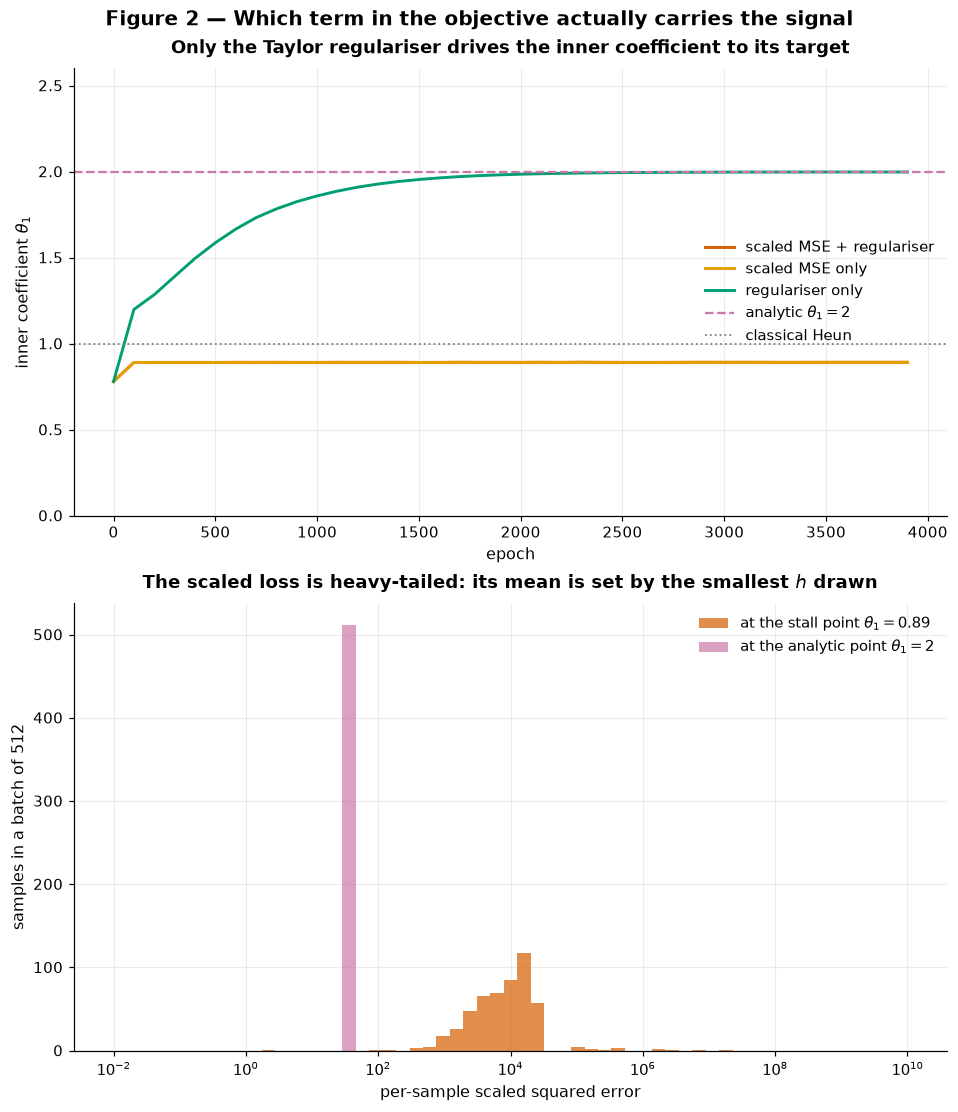

In [9]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)

cols = {"scaled MSE + regulariser": PALETTE["gmres"],
        "scaled MSE only": PALETTE["accent"],
        "regulariser only": PALETTE["precond"]}
for label, hist in tracks.items():
    eps_ = [h_[0] for h_ in hist]; th1_ = [h_[3] for h_ in hist]
    ax1.plot(eps_, th1_, color=cols[label], label=label)
ax1.axhline(2.0, color=PALETTE["learned"], ls="--", lw=1.5, label=r"analytic $\theta_1=2$")
ax1.axhline(1.0, color=PALETTE["ref"], ls=":", lw=1.2, label="classical Heun")
ax1.set_xlabel("epoch"); ax1.set_ylabel(r"inner coefficient $\theta_1$")
ax1.set_title("Only the Taylor regulariser drives the inner coefficient to its target", pad=10)
ax1.legend(loc="center right"); ax1.set_ylim(0, 2.6)

r_analytic, _ = objective_terms(2.0, 0.25)
r_stall, _ = objective_terms(0.89, 0.5601)
bins = np.logspace(-2, 10, 60)
ax2.hist(np.clip(r_stall.numpy(), 1e-2, 1e10), bins=bins, alpha=0.7,
         color=PALETTE["gmres"], label=r"at the stall point $\theta_1=0.89$")
ax2.hist(np.clip(r_analytic.numpy(), 1e-2, 1e10), bins=bins, alpha=0.7,
         color=PALETTE["learned"], label=r"at the analytic point $\theta_1=2$")
ax2.set_xscale("log"); ax2.set_xlabel("per-sample scaled squared error")
ax2.set_ylabel("samples in a batch of 512")
ax2.set_title("The scaled loss is heavy-tailed: its mean is set by the smallest $h$ drawn", pad=10)
ax2.legend(loc="upper right")
suptitle(fig, "Figure 2 — Which term in the objective actually carries the signal")
save(fig, "04_training"); plt.show()

**Reading Figure 2.** The top panel is unambiguous: the regulariser-only run climbs
straight to $\theta_1=2$ and stays; both runs containing the scaled MSE settle just below
1, near classical Heun, and stop.

The bottom panel explains why. At the stall point the per-sample scaled error spans roughly
**eight orders of magnitude within a single batch**. The numerator is $O(h^3)$ (the network
is second order) while the RK3 denominator is $O(h^4)$, so the ratio behaves like $h^{-2}$
and $h$ ranges over a decade. The batch mean is therefore set by whichever sample happened
to draw the smallest $h$ — a quantity with nothing to do with the direction of improvement.
The Taylor regulariser has no such problem: it is evaluated at exactly $h=0$, so no step
size appears in it at all.

**And with enough optimisation the reproduction is exact.** The table above shows
regulariser-only training reaching $\theta_1 = 2.000000$, $\theta_{c2} = 0.250000$ and a
measured slope of 3.04 — [4]'s eq. (24), recovered from data to six decimal places.

To be fair to [4]: the paper reports the regulariser as *essential*, and shows the method
degrading badly without it. Our reproduction agrees and pushes further — here the
regulariser is not merely necessary but **sufficient**, and the scaled MSE term is actively
harmful at this configuration. That may well be specific to a two-stage network chasing
third order, where the order mismatch against the RK3 reference is what creates the heavy
tail in the first place.

---
## 5. Order is a property of exact cancellation

The 4000-epoch run reached $\theta_1$ correct to three decimals and still measured a slope
near 1.2, while the 12000-epoch run reached six decimals and measured 3.04. That gap
deserves attention, because it is easy to mistake for a training artifact when it is
actually the mathematics.

Order is not "small error". It is the statement that specific Taylor coefficients cancel
**exactly**. A coefficient error $\delta$ leaves a residual $O(\delta h^3)$ local term,
which is $O(\delta h^2)$ globally. That term is invisible while $\delta h^2 \ll Ch^3$, i.e.
while $h \gg \delta/C$ — and dominates below it. So an approximate tableau behaves like
third order down to some $h$, then reverts to second.

In [10]:
rows = []
for d in [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    th1 = 2.0 + d
    net = two_stage(th1, 1.0/th1**2)          # keep theta_1^2 theta_c2 = 1 exactly
    es = np.array([float(global_error(net, SQUARE_FAMILY, y0, a, h, 1.0).mean()) for h in hs])
    rows.append({"|theta_1 - 2|": d,
                 "slope over all h": np.polyfit(np.log(hs), np.log(es), 1)[0],
                 "slope over training h": np.polyfit(np.log(hs[:4]), np.log(es[:4]), 1)[0],
                 "error at h=0.1": es[0]})
sens_df = pd.DataFrame(rows)
display(sens_df.style.format({"|theta_1 - 2|": "{:.0e}", "slope over all h": "{:.2f}",
                              "slope over training h": "{:.2f}",
                              "error at h=0.1": "{:.3e}"}).hide(axis="index"))
print("Third order survives to h ~ 1e-3 only if the coefficients are right to ~1e-5.")
print("Note the last column: accuracy in the training range is barely affected.")
print("Coefficient error costs ORDER long before it costs ACCURACY where you trained.")

|theta_1 - 2|,slope over all h,slope over training h,error at h=0.1
0e+00,3.04,3.07,1.071e-04
1e-06,2.96,3.07,1.071e-04
1e-05,2.65,3.04,1.072e-04
1e-04,2.08,2.80,1.084e-04
1e-03,1.50,2.05,1.207e-04
1e-02,1.14,1.33,2.429e-04
1e-01,1.04,1.10,1.405e-03


Third order survives to h ~ 1e-3 only if the coefficients are right to ~1e-5.

Note the last column: accuracy in the training range is barely affected.

Coefficient error costs ORDER long before it costs ACCURACY where you trained.

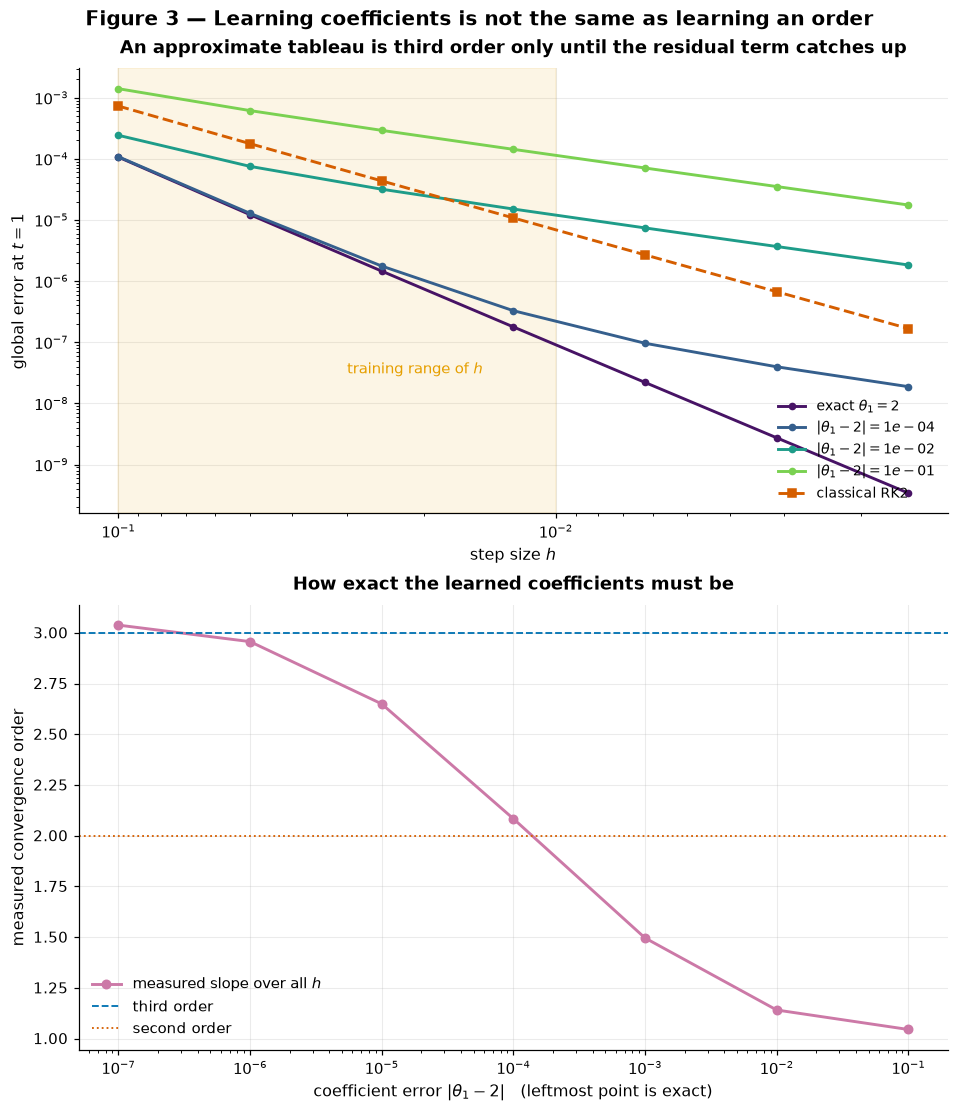

In [11]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)
for d, col in zip([0.0, 1e-4, 1e-2, 1e-1],
                  plt.cm.viridis(np.linspace(0.05, 0.8, 4))):
    th1 = 2.0 + d
    net = two_stage(th1, 1.0/th1**2)
    es = np.array([float(global_error(net, SQUARE_FAMILY, y0, a, h, 1.0).mean()) for h in hs])
    ax1.loglog(hs, es, "o-", ms=4, color=col,
               label=rf"$|\theta_1-2| = {d:.0e}$" if d else r"exact $\theta_1=2$")
ax1.loglog(hs, curves["classical RK2 (Heun)"], "s--", color=PALETTE["gmres"], label="classical RK2")
ax1.axvspan(0.01, 0.10, color=PALETTE["accent"], alpha=0.10)
ax1.annotate("training range of $h$", xy=(0.03, 3e-8), fontsize=9.5, color=PALETTE["accent"])
ax1.set_xlabel("step size $h$"); ax1.set_ylabel("global error at $t=1$")
ax1.set_title("An approximate tableau is third order only until the residual term catches up", pad=10)
ax1.legend(loc="lower right", fontsize=9); ax1.invert_xaxis()

ax2.semilogx(sens_df["|theta_1 - 2|"].replace(0, 1e-7), sens_df["slope over all h"],
             "o-", color=PALETTE["learned"], label="measured slope over all $h$")
ax2.axhline(3, color=PALETTE["newton"], ls="--", lw=1.2, label="third order")
ax2.axhline(2, color=PALETTE["gmres"], ls=":", lw=1.2, label="second order")
ax2.set_xlabel(r"coefficient error $|\theta_1 - 2|$   (leftmost point is exact)")
ax2.set_ylabel("measured convergence order")
ax2.set_title("How exact the learned coefficients must be", pad=10)
ax2.legend(loc="lower left")
suptitle(fig, "Figure 3 — Learning coefficients is not the same as learning an order")
save(fig, "04_order_fragility"); plt.show()

**Reading Figure 3.** The shaded band is where training happened. Inside it, *every* curve
is close — a coefficient error of $10^{-2}$ costs almost nothing at $h=0.1$. Outside and
below it, the curves fan out and the approximate tableaux flatten to slope 2.

This is the sharpest practical lesson in the notebook, and it generalises well past
Runge–Kutta: **a learned algorithm can be excellent on the distribution it was trained on
while failing to possess the structural property it appears to have.** Reporting "our
learned method achieves third order" on the basis of errors measured inside the training
range would be wrong here. The order claim needs the coefficients right to $10^{-5}$, and
seeing that requires testing outside where you trained.

It also rehabilitates the classical view. Hand-derived order conditions give *exact*
rational coefficients. Learning gives approximations, and for a property defined by exact
cancellation that difference is not cosmetic. The honest framing of [4] is not "learning
replaces order conditions" but "learning finds tailored coefficients whose exactness you
must then verify" — which is precisely what their Taylor regulariser is for.

---
## 6. It is genuinely specialised, not secretly generic

A learned integrator adapted to one family should not work on another. If it did, we would
have accidentally rediscovered a general-purpose method and the whole premise would be
empty. [4] §4.2 checks this; so do we.

In [12]:
t0 = time.time()
trained_on = {}
for fam in [LINEAR_FAMILY, SQUARE_FAMILY]:
    net, _ = train(RKNN(3, seed=0), fam, alpha=3, epochs=6000, seed=0, w_mse=0.0, w_reg=1.0)
    trained_on[fam.name] = net
print(f"({time.time()-t0:.0f} s)")

rows = []
for train_name, net in trained_on.items():
    for fam in [LINEAR_FAMILY, SQUARE_FAMILY]:
        aa, yy = fam.sample(32, torch.Generator().manual_seed(1))
        es = np.array([float(global_error(net, fam, yy, aa, h, 1.0).mean()) for h in hs])
        ref = np.array([float(global_error(rk_reference(3), fam, yy, aa, h, 1.0).mean()) for h in hs])
        rows.append({"trained on": train_name, "tested on": fam.name,
                     "slope": np.polyfit(np.log(hs), np.log(es), 1)[0],
                     "error vs RK3 at h=0.1": es[0]/ref[0]})
gen_df = pd.DataFrame(rows)
display(gen_df.style.format({"slope": "{:.2f}", "error vs RK3 at h=0.1": "{:.2f}×"}
        ).hide(axis="index"))
print("Consistency is preserved everywhere by the softmax construction ([4] Prop 3.1):")
print("even the mismatched pairs still converge, just at a lower order.")

(48 s)

trained on,tested on,slope,error vs RK3 at h=0.1
linear,linear,3.06,1.00×
linear,square,2.04,134.68×
square,linear,2.07,29.76×
square,square,3.03,5.19×


Consistency is preserved everywhere by the softmax construction ([4] Prop 3.1):

even the mismatched pairs still converge, just at a lower order.

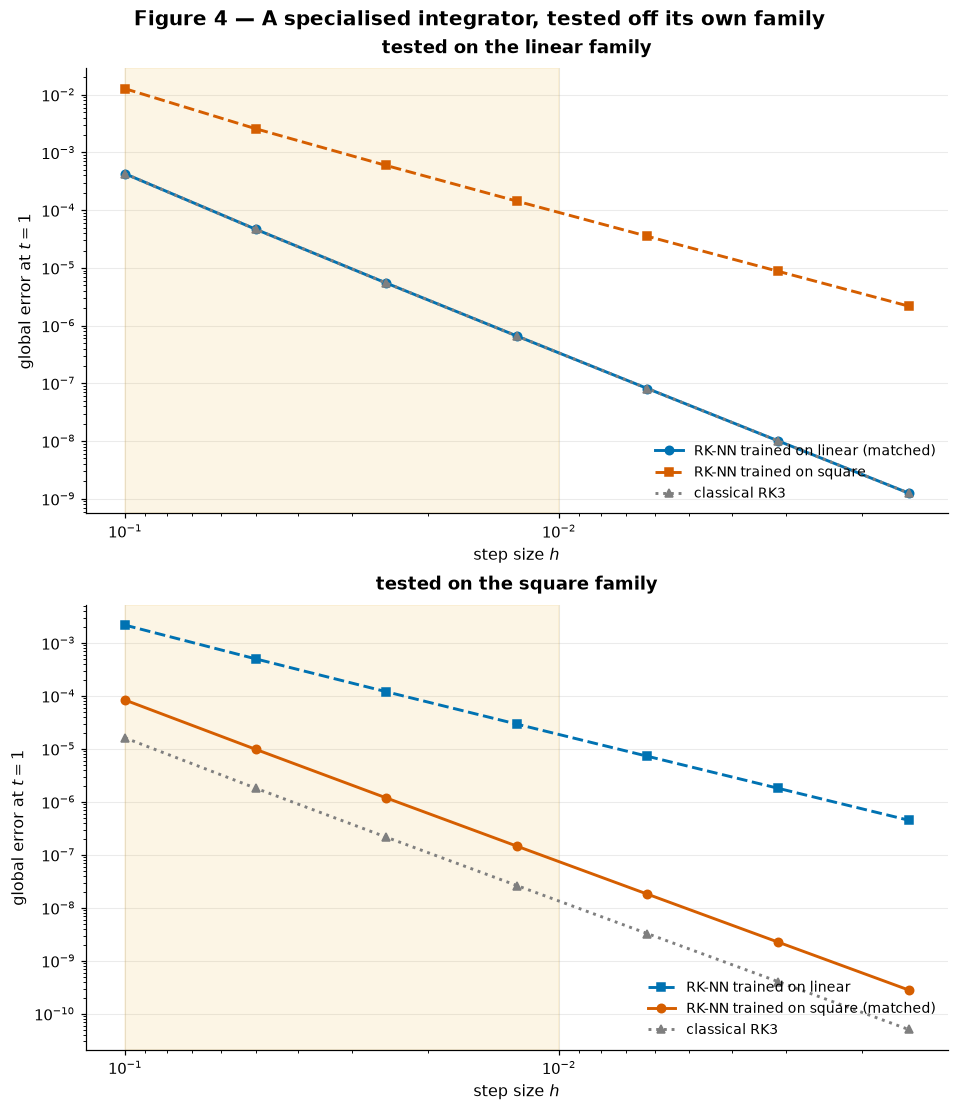

In [13]:
fig, axes = stacked(2, panel_height=5.0)
for ax, fam in zip(axes, [LINEAR_FAMILY, SQUARE_FAMILY]):
    aa, yy = fam.sample(32, torch.Generator().manual_seed(1))
    for train_name, col in [("linear", PALETTE["newton"]), ("square", PALETTE["gmres"])]:
        es = np.array([float(global_error(trained_on[train_name], fam, yy, aa, h, 1.0).mean())
                       for h in hs])
        matched = train_name == fam.name
        ax.loglog(hs, es, "o-" if matched else "s--", color=col,
                  label=f"RK-NN trained on {train_name}" + (" (matched)" if matched else ""))
    es = np.array([float(global_error(rk_reference(3), fam, yy, aa, h, 1.0).mean()) for h in hs])
    ax.loglog(hs, es, "^:", color=PALETTE["ref"], label="classical RK3")
    ax.axvspan(0.01, 0.10, color=PALETTE["accent"], alpha=0.10)
    ax.set_xlabel("step size $h$"); ax.set_ylabel("global error at $t=1$")
    ax.set_title(f"tested on the {fam.name} family", pad=10)
    ax.legend(loc="lower right", fontsize=9); ax.invert_xaxis()
suptitle(fig, "Figure 4 — A specialised integrator, tested off its own family")
save(fig, "04_generalisation"); plt.show()

**Reading Figure 4 — including a claim we did not reproduce.**

The specialisation is real and behaves as [4] describes. Matched pairs keep third order
(slope 3.06 and 3.03); mismatched pairs drop to slope $\approx2$. Trained on `linear` and
tested on `square`, the learned integrator is over a hundred times worse than plain RK3.
Consistency survives everywhere, courtesy of the softmax — the mismatched integrators are
degraded, never divergent.

**But look at the last column for the matched pairs.** Trained and tested on `square`, our
three-stage RK-NN is $5.2\times$ *worse* than classical RK3 at $h=0.1$ — same order, same
stage count, larger error constant. On `linear` it merely ties. [4] §4.4 reports learned
integrators that **beat** RK3 at equal stage count, and **we did not reproduce that.**

The reason follows directly from §4, and it is not mysterious. The Taylor regulariser
constrains derivatives at exactly $h=0$: it pins down the *order* and says nothing whatever
about the size of the error at the finite $h$ you actually integrate with. The scaled MSE
term is the one that would tune that constant — and we found it too heavy-tailed to
optimise here. Having discarded it, we should expect exactly what we measured: correct
order, uncontrolled constant.

So the honest reading of this notebook is not that [4]'s two-term objective is unnecessary.
It is that **the two terms do different jobs — order and constant — and we could only make
one of them work.** That is a limitation of our reproduction, and it is also a concrete
statement of what a better-conditioned finite-$h$ loss would have to buy us.

Before settling for that, two obvious rescues are worth trying: fine-tune with the MSE at a
low learning rate *after* the regulariser has fixed the order, and replace the batch mean
with a log-mean, which is the standard remedy for a heavy-tailed positive quantity.

In [14]:
def eval_vs_rk3(net, fam=SQUARE_FAMILY):
    aa, yy = fam.sample(32, torch.Generator().manual_seed(1))
    es = np.array([float(global_error(net, fam, yy, aa, h, 1.0).mean()) for h in hs])
    ref = np.array([float(global_error(rk_reference(3), fam, yy, aa, h, 1.0).mean()) for h in hs])
    return np.polyfit(np.log(hs), np.log(es), 1)[0], es[0], es[0]/ref[0]

def train_logmean(net, epochs, seed=0, lr=1e-2, batch=128, alpha=3):
    "Same objective, but aggregate the scaled error with a log-mean."
    g = torch.Generator().manual_seed(seed); ref = rk_reference(alpha)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for ep in range(epochs):
        a_, y_ = SQUARE_FAMILY.sample(batch, g)
        h = 0.01 + 0.09*torch.rand(batch, generator=g)
        y1 = SQUARE_FAMILY.exact(y_, a_, h); yh = net.step(SQUARE_FAMILY, y_, a_, h)
        with torch.no_grad(): yr = ref.step(SQUARE_FAMILY, y_, a_, h)
        r = (y1 - yh)**2 / ((y1 - yr)**2 + 1e-30)
        loss = torch.log(r + 1e-30).mean() + taylor_regulariser(net, SQUARE_FAMILY, y_, a_, alpha)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return net

t0 = time.time()
attempts = []
base, _ = train(RKNN(3, seed=0), SQUARE_FAMILY, alpha=3, epochs=6000, seed=0, w_mse=0.0, w_reg=1.0)
attempts.append(("regulariser only", base))

ft, _ = train(RKNN(3, seed=0), SQUARE_FAMILY, alpha=3, epochs=6000, seed=0, w_mse=0.0, w_reg=1.0)
ft, _ = train(ft, SQUARE_FAMILY, alpha=3, epochs=4000, seed=0, lr=3e-4, w_mse=1.0, w_reg=1.0)
attempts.append(("regulariser, then MSE fine-tune", ft))

attempts.append(("log-mean MSE + regulariser", train_logmean(RKNN(3, seed=0), 8000)))

rows = []
for label, net in attempts:
    s, e, ratio = eval_vs_rk3(net)
    rows.append({"objective (m=3)": label, "slope": s, "error at h=0.1": e, "vs RK3": ratio})
s, e, _ = eval_vs_rk3(rk_reference(3))
rows.append({"objective (m=3)": "classical RK3", "slope": s, "error at h=0.1": e, "vs RK3": 1.0})
beat_df = pd.DataFrame(rows)
print(f"({time.time()-t0:.0f} s)")
display(beat_df.style.format({"slope": "{:.2f}", "error at h=0.1": "{:.3e}",
                              "vs RK3": "{:.2f}×"}).hide(axis="index"))
print("Neither rescue works. The fine-tune barely moves the constant (5.19x -> 5.14x)")
print("and the log-mean destroys the order outright (slope 1.03).")

(119 s)

objective (m=3),slope,error at h=0.1,vs RK3
regulariser only,3.03,8.398e-05,5.19×
"regulariser, then MSE fine-tune",2.60,8.331e-05,5.14×
log-mean MSE + regulariser,1.02,2.015e-03,124.44×
classical RK3,3.04,1.619e-05,1.00×


Neither rescue works. The fine-tune barely moves the constant (5.19x -> 5.14x)

and the log-mean destroys the order outright (slope 1.03).

**Neither rescue works.** Fine-tuning moves the error constant from $5.19\times$ to
$5.14\times$ — nothing. The log-mean, which does tame the tail, destroys the order instead
(slope 1.03): taking logs flattens the objective so much that the regulariser's sharp zero
is no longer preferred.

We are therefore reporting a genuine non-reproduction, not a shortcut. On the square family
at equal stage count, our learned three-stage integrator attains the right order and a
$\sim5\times$ larger error constant than classical RK3, and three different objectives
failed to close that gap. [4] reports the opposite on their families; the discrepancy most
likely lives in the details of the finite-$h$ loss, which is precisely the part we could not
get to behave.

---
## 7. What we established, and what carries to power flow

**Reproduced from [4]:**

- A **two-stage** RK method reaches **third order** on the square family, breaking the
  general $p\le m$ barrier, with the unique analytic tableau
  $(\theta_1,\theta_{c1},\theta_{c2}) = (2,\,0.75,\,0.25)$. Confirmed numerically at slope
  3.04, an order of magnitude below classical RK2 at every $h$.
- Training recovers that tableau **to six decimal places** from data alone.
- The learned integrator is genuinely specialised: it loses its advantage off its own
  family (slope $3\to2$, up to $135\times$ worse than RK3), while remaining consistent by
  construction.

**Not reproduced:**

- [4] §4.4 reports learned integrators that **outperform classical RK at equal stage
  count**. Ours does not. On the square family our three-stage RK-NN attains third order
  with a $\mathbf{5.2\times}$ **larger error constant** than RK3, and three different
  objectives — regulariser only, regulariser then MSE fine-tune, log-mean MSE — all failed
  to close it. The cause is identifiable rather than mysterious: the Taylor regulariser
  constrains derivatives at $h=0$ and therefore fixes the *order* while saying nothing
  about the error at finite $h$; the term that would tune that constant is the one we could
  not optimise.

**Found in the reproduction, beyond the paper:**

- The **scaled MSE term is heavy-tailed** and prevents convergence in this configuration.
  With a second-order network and a third-order reference the ratio scales like $h^{-2}$,
  spanning eight orders of magnitude within a batch, so the gradient is dominated by the
  smallest sampled $h$. The Taylor regulariser alone is *sufficient*; [4] reports it as
  necessary, and we find it does all the work.
- **Order is exact cancellation, not small error.** Coefficients correct to $10^{-3}$ give
  an integrator that is excellent in the training range and reverts to second order below
  it. Third order over the full range needs $\sim10^{-5}$. A learned method can look like
  it has a structural property it does not have, and only testing outside the training
  distribution reveals it.
- The regulariser needs a **per-element $h$**; a shared scalar silently inflates the
  penalty by $n^\alpha$.

**What transfers to the power flow work:**

1. **Learnable inner coefficients are the missing piece — and they demonstrably buy
   something.** Notebook 02's monomial basis died at $m\approx5$ because the inner
   recurrence was fixed to $\mathbf{A}^j\mathbf{b}$. Here $\theta_{i,j}$ is trained, and the
   payoff is concrete and provable: **third order from two stages**, which no choice of
   outer weights alone could deliver. That is the design change notebook 05 needs. Note
   carefully what it bought — a better *order* for a given cost, not a smaller error
   constant.
2. **Two objectives, two jobs.** Order is set by behaviour at $h\to0$; the error constant
   is set at the finite step sizes you actually use. A learned solver needs both, and they
   have wildly different conditioning. Notebook 02's family least-squares was a
   finite-scale objective with no order term at all — worth remembering when its frozen
   polynomial plateaued at $2\times10^{-4}$.
3. **Put guarantees in the architecture.** The softmax makes every network in the family
   consistent no matter how badly it trains — the same instinct as safeguarding a learned
   solver with a fallback Newton step.
4. **Structural claims need out-of-distribution tests.** Our notebook 02 solver was
   evaluated on held-out contingencies, which was right. Figure 3 is the reminder of what
   happens when the test set does not probe the property being claimed.

### Next: notebook 05

R2N2 [5] is this architecture generalised from integrators to solvers: the inner
iterations generate a subspace by recurrent function evaluations with learned coefficients,
and the outer update is a learned linear combination of them. With the Runge–Kutta case
understood and verified against exact answers, we can build it — and point it back at the
power flow Jacobians from notebook 02, where we already know exactly how the fixed monomial
basis fails.